In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier

import os ,sys
sys.path.append(os.path.abspath(".."))

from src.preprocessing import preprocess
from src.feature_engineering import create_features

In [4]:
# ==========================================
# Load Dataset
# ==========================================
TARGET = "health_condition"
TRAIN_PATH = "../data/train.csv"
TEST_PATH = "../data/test.csv"
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

train.head()

Train Shape : (690088, 15)
Test Shape  : (295753, 14)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [5]:
# ==========================================
# Save IDs
# ==========================================

train_ids = train["id"].copy()

test_ids = test["id"].copy()

In [6]:
# ==========================================
# Preprocessing
# ==========================================

train = preprocess(train)
test = preprocess(test)

print(train.shape)
print(test.shape)

(690088, 14)
(295753, 13)


In [7]:
# ==========================================
# Feature Engineering V2
# ==========================================

train = create_features(train)
test = create_features(test)

print(train.shape)
print(test.shape)

(690088, 34)
(295753, 33)


In [8]:
# ==========================================
# Prepare Features
# ==========================================

X = train.drop(columns=[TARGET]).copy()

y = train[TARGET].copy()

print("Features :", X.shape)

print("Target   :", y.shape)

Features : (690088, 33)
Target   : (690088,)


In [9]:
import json

with open("../output/models/best_params.json", "r") as f:
    best_params = json.load(f)

best_params

{'bootstrap_type': 'Bernoulli',
 'learning_rate': 0.03309416821002669,
 'depth': 7,
 'l2_leaf_reg': 10.801507310686478,
 'random_strength': 0.898531201248234,
 'border_count': 253,
 'grow_policy': 'Depthwise',
 'leaf_estimation_iterations': 9,
 'min_data_in_leaf': 25,
 'subsample': 0.6828948177465322,
 'iterations': 1200,
 'loss_function': 'MultiClass',
 'eval_metric': 'MultiClass',
 'task_type': 'GPU',
 'devices': '0',
 'random_seed': 42,
 'verbose': 200,
 'auto_class_weights': 'Balanced'}

In [10]:
model = CatBoostClassifier(
    **best_params
)

In [11]:
from catboost import CatBoostClassifier

# Get categorical feature names
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Initialize model
model = CatBoostClassifier(**best_params)

# Train model
model.fit(
    X,
    y,
    cat_features=categorical_features,
    verbose=100
)

print("✅ Model training completed!")

/tmp/ipykernel_10821/3213397144.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


0:	learn: 0.9994171	total: 96.2ms	remaining: 1m 55s
100:	learn: 0.1694524	total: 8.1s	remaining: 1m 28s
200:	learn: 0.1608484	total: 15.7s	remaining: 1m 18s
300:	learn: 0.1542088	total: 22.9s	remaining: 1m 8s
400:	learn: 0.1481807	total: 30s	remaining: 59.8s
500:	learn: 0.1424916	total: 37.2s	remaining: 51.9s
600:	learn: 0.1370857	total: 44.5s	remaining: 44.3s
700:	learn: 0.1322535	total: 51.7s	remaining: 36.8s
800:	learn: 0.1277069	total: 59s	remaining: 29.4s
900:	learn: 0.1234268	total: 1m 6s	remaining: 22s
1000:	learn: 0.1194156	total: 1m 13s	remaining: 14.6s
1100:	learn: 0.1154308	total: 1m 21s	remaining: 7.31s
1199:	learn: 0.1117493	total: 1m 28s	remaining: 0us
✅ Model training completed!


In [12]:
print(model.get_best_score())

{'learn': {'MultiClass': 0.11174927208619309}}


In [14]:
# Sample data for SHAP analysis
sample_size = 5000

X_sample = X.sample(
    n=sample_size,
    random_state=42
)

print(X_sample.shape)

(5000, 33)


In [15]:
# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values computed!")

✅ SHAP values computed!


In [16]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    print("Shape of first class:", shap_values[0].shape)
else:
    print("Shape:", shap_values.shape)

<class 'numpy.ndarray'>
Shape: (5000, 33, 3)


In [17]:
class_names = model.classes_

print(class_names)

['at-risk' 'fit' 'unhealthy']


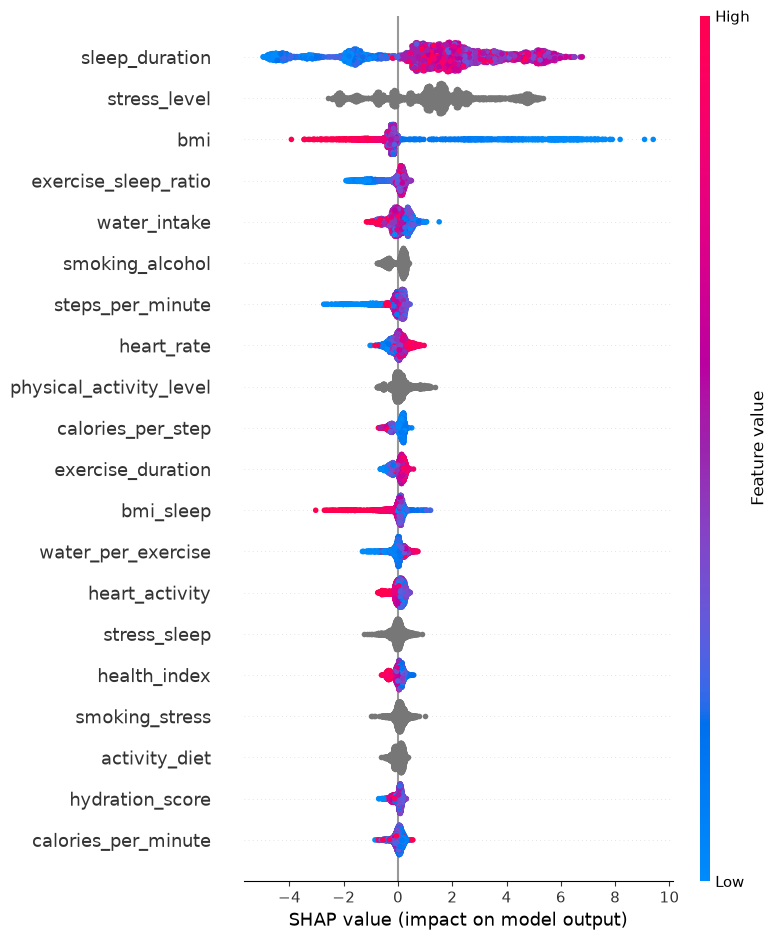

In [18]:
import shap

shap.summary_plot(
    shap_values[:, :, 0],
    X_sample,
    feature_names=X_sample.columns
)

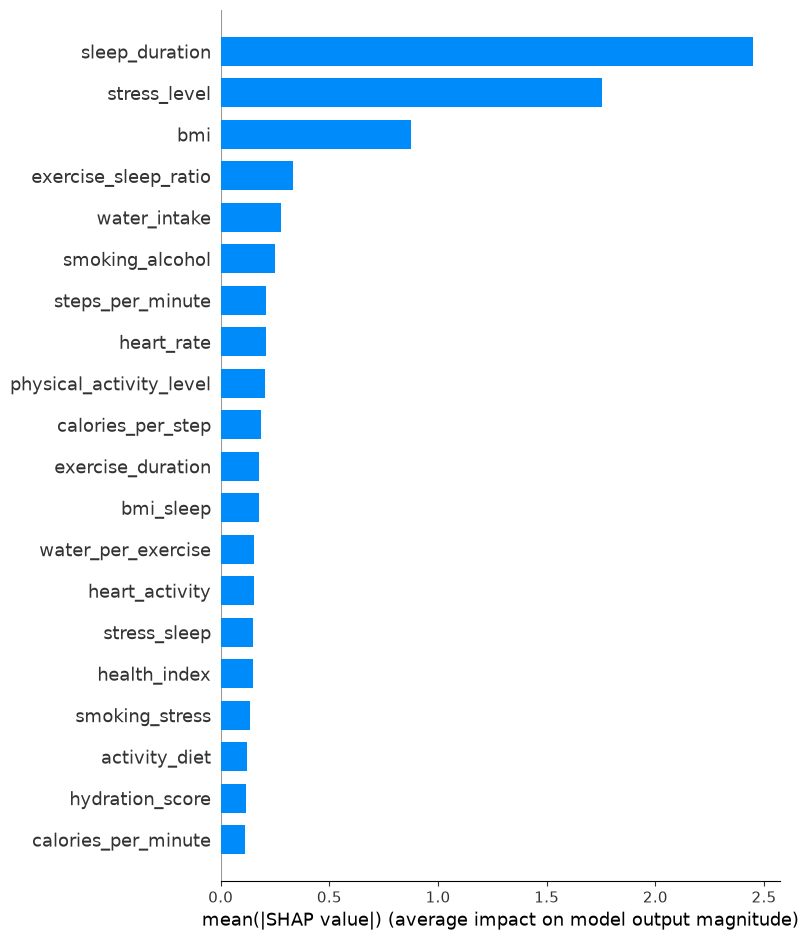

In [19]:
shap.summary_plot(
    shap_values[:, :, 0],
    X_sample,
    feature_names=X_sample.columns,
    plot_type="bar"
)

In [21]:
# Calculate mean absolute SHAP value for each feature
feature_importance = pd.DataFrame({
    "Feature": X_sample.columns,
    "Mean |SHAP|": np.abs(shap_values[:, :, 0]).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    by="Mean |SHAP|",
    ascending=False
)

feature_importance.reset_index(drop=True, inplace=True)

feature_importance.head(15)

,Feature,Mean |SHAP|
0,sleep_duration,2.450912
1,stress_level,1.752754
2,bmi,0.873590
3,exercise_sleep_ratio,0.331920
4,water_intake,0.279618
5,smoking_alcohol,0.248423
6,steps_per_minute,0.210405
7,heart_rate,0.209457
8,physical_activity_level,0.204566
9,calories_per_step,0.183335


In [22]:
feature_importance.to_csv(
    "../output/shap_feature_importance.csv",
    index=False
)

print("✅ SHAP feature importance saved.")

✅ SHAP feature importance saved.


In [23]:
from pathlib import Path

Path("../output").mkdir(exist_ok=True)

In [24]:
for i, cls in enumerate(class_names):

    importance = pd.DataFrame({
        "Feature": X_sample.columns,
        "Mean |SHAP|": np.abs(shap_values[:, :, i]).mean(axis=0)
    })

    importance = importance.sort_values(
        by="Mean |SHAP|",
        ascending=False
    )

    print(f"\nTop 10 Features for {cls}")
    display(importance.head(10))


Top 10 Features for at-risk


,Feature,Mean |SHAP|
0,sleep_duration,2.450912
8,stress_level,1.752754
2,bmi,0.873590
16,exercise_sleep_ratio,0.331920
6,water_intake,0.279618
11,smoking_alcohol,0.248423
17,steps_per_minute,0.210405
1,heart_rate,0.209457
10,physical_activity_level,0.204566
14,calories_per_step,0.183335



Top 10 Features for fit


,Feature,Mean |SHAP|
0,sleep_duration,2.187330
2,bmi,1.484141
8,stress_level,1.155641
10,physical_activity_level,0.961120
6,water_intake,0.513976
11,smoking_alcohol,0.484476
16,exercise_sleep_ratio,0.378842
17,steps_per_minute,0.252602
21,heart_steps,0.241733
30,gender_activity,0.237770



Top 10 Features for unhealthy


,Feature,Mean |SHAP|
0,sleep_duration,0.010168
8,stress_level,0.003951
28,stress_sleep,0.003791
2,bmi,0.003603
11,smoking_alcohol,0.002831
10,physical_activity_level,0.002018
22,bmi_sleep,0.002018
29,activity_diet,0.001962
1,heart_rate,0.001893
3,calorie_expenditure,0.001693


# Conclusion

The SHAP analysis provides insights into the CatBoost model's decision-making process.

## Key Findings

- Sleep Duration is the most influential feature across all health risk categories.
- Stress Level and BMI are consistently among the top predictors.
- Physical Activity and Water Intake significantly contribute to identifying healthy students.
- Engineered features such as Exercise-Sleep Ratio, Stress-Sleep Interaction, and Gender-Activity Interaction improve model interpretability and predictive performance.
- The SHAP analysis confirms that the model relies on meaningful health-related factors rather than random correlations.

Overall, the explainability results increase confidence in the CatBoost model and demonstrate that it learns clinically and behaviorally relevant patterns for student health risk prediction.